# Chess Accuracy Analysis

This notebook presents an analysis of high-level chess games using the Lichess Elite Database.

The goals of the projects are:

1. First part -- Statistical Insights

In this section, we explore global patterns in chess performance based on accuracy and opening theory.

- Which players show the highest move accuracy?
- Which openings are more stable and which are more tactical?
- How does the probability of winning change as moves are played?

2. Second part -- Interactive Exploration 

To make the analysis more intuitive, I built an interactive streamlit application that allows users to play moves on a virtual chessboard and see real-time statistics for the exact sequence played.


In [77]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")

from ranking import Ranking
from accuracy import compute_accuracy
from opening_stats import opening_stability, prefix_stats

# Paths

BASE_DIR = "../"
DATA_DIR = BASE_DIR + "data/processed/"

df = pd.read_csv(DATA_DIR + "chess_dataset.csv")
df_acc = pd.read_csv(DATA_DIR + "df_accuracy.csv")
df_prefix = pd.read_csv(DATA_DIR + "prefix_stats.csv")

# Clean df
df = df.drop(columns=["Unnamed: 0","moves"])
df.index = df.index + 1
df.index.name = None


df.head()


,white,black,result,opening,eco,num_moves,moves_preview
1,Matetricks,nicky,1-0,Scandinavian Defense: Main Line,B01,57,"['e2e4', 'd7d5', 'e4d5']"
2,nicky,Matetricks,0-1,Richter-Veresov Attack,D01,52,"['d2d4', 'd7d5', 'b1c3']"
3,nicky,Matetricks,0-1,"Queen's Pawn Game: Veresov Attack, Two Knights...",D01,74,"['d2d4', 'd7d5', 'b1c3']"
4,Matetricks,nicky,1-0,Scandinavian Defense: Main Line,B01,81,"['e2e4', 'd7d5', 'e4d5']"
5,geochess,Matetricks,0-1,King's Indian Attack,A08,48,"['g1f3', 'g8f6', 'g2g3']"


In [94]:
df_acc.index = df_acc.index + 1
ranker = Ranking(df_acc, min_moves=2, min_games=2)

top_white = ranker.ranking_color("white")
top_black = ranker.ranking_color("black")
top_overall = ranker.ranking_overall().head(10)

top_overall.index = top_overall.index + 1
top_overall.head(10)

,player,accuracy
1,starlightextinction,0.860
2,soldier14,0.855
3,tomekas1,0.835
4,masterhec,0.805
5,ashkan12,0.800
6,Rappozevich,0.785
7,Mikefreeman,0.775
8,ohsusanna,0.770
9,Lola3745,0.770
10,NHN16,0.765


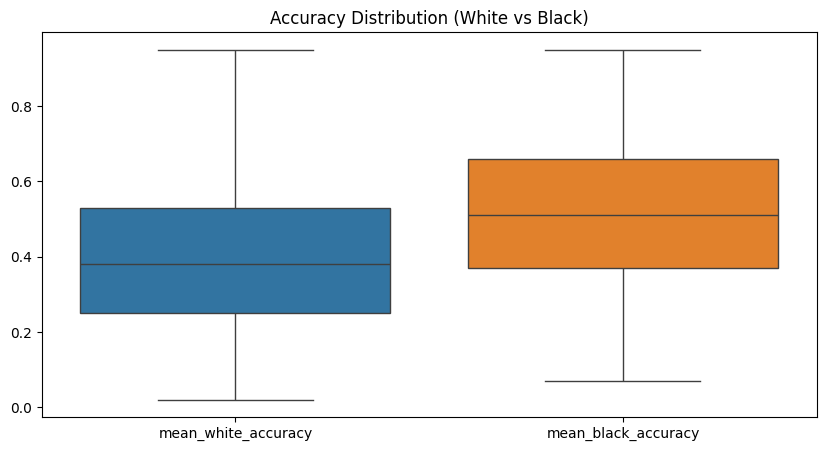

In [98]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_acc[["mean_white_accuracy", "mean_black_accuracy"]])
plt.title("Accuracy Distribution (White vs Black)")
plt.show()

In [125]:
df_openings = opening_stability(df_acc)
df_openings = df_openings[df_openings["games"] > 10]

# Select the most stable openings

top_openings = df_openings.sort_values("stability_std").head(10).reset_index(drop=True)

top_openings.index = top_openings.index + 1

top_openings

,opening,eco,mean_accuracy,stability_std,games
1,Sicilian Defense: Kalashnikov Variation,B32,0.390000,0.079906,11
2,Sicilian Defense: Closed Variation,B23,0.537059,0.113248,17
3,English Opening: King's English Variation,A20,0.428182,0.118031,11
4,King's Indian Defense: Orthodox Variation,E91,0.460769,0.125081,13
5,Modern Defense: Standard Defense,B06,0.492857,0.127532,14
6,Queen's Pawn Game: Mason Attack,D00,0.426563,0.138537,16
7,Trompowsky Attack,A45,0.437381,0.148641,21
8,Indian Game,A45,0.466607,0.152613,28
9,Zukertort Opening: Kingside Fianchetto,A04,0.486429,0.154564,14
10,Horwitz Defense,A40,0.431538,0.166162,13


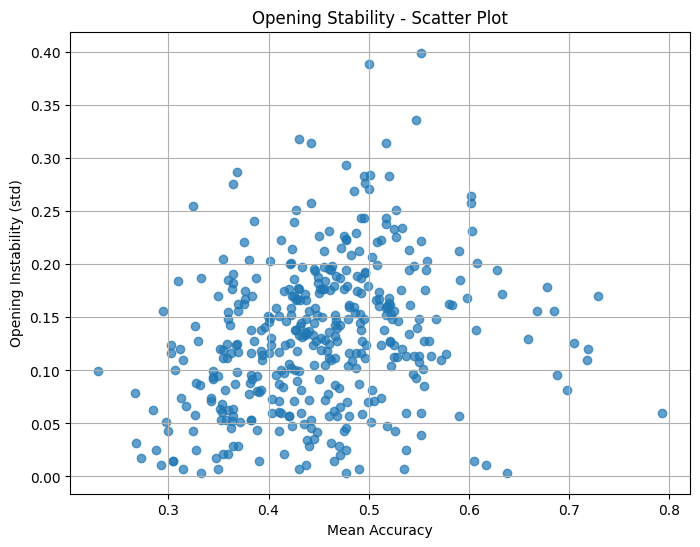

In [126]:
df_openings = opening_stability(df_acc)

plt.figure(figsize=(8,6))
plt.scatter(df_openings["mean_accuracy"], 
            df_openings["stability_std"],
            alpha=0.7
            )
plt.xlabel("Mean Accuracy")
plt.ylabel("Opening Instability (std)")
plt.title("Opening Stability - Scatter Plot")
plt.grid(True)
plt.show()

In [114]:
df_prefix[df_prefix["count"] > 10].head(10)

,prefix,count,white_win_rate,black_win_rate,draw_rate,main_opening
26,"('b1c3',)",18,0.167,0.667,0.167,Van Geet Opening
155,"('b2b3',)",29,0.655,0.345,0.000,Nimzo-Larsen Attack: Classical Variation
340,"('b2b4',)",11,0.455,0.545,0.000,Polish Opening
435,"('c2c4',)",124,0.548,0.395,0.056,English Opening: King's English Variation
456,"('c2c4', 'c7c5')",22,0.636,0.318,0.045,English Opening: Symmetrical Variation
667,"('c2c4', 'e7e5')",28,0.571,0.393,0.036,English Opening: King's English Variation
668,"('c2c4', 'e7e5', 'b1c3')",16,0.438,0.562,0.000,"English Opening: King's English Variation, Kra..."
823,"('c2c4', 'e7e6')",11,0.545,0.455,0.000,English Opening: Agincourt Defense
965,"('c2c4', 'g8f6')",37,0.514,0.378,0.108,English Opening: Anglo-Indian Defense
966,"('c2c4', 'g8f6', 'b1c3')",21,0.571,0.429,0.000,"English Opening: Anglo-Indian Defense, Queen's..."


In [ ]:
common_prefixes = (
    df_prefix
    .sort_values("count", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

common_prefixes.index = common_prefixes.index + 1

common_prefixes

,prefix,count,white_win_rate,black_win_rate,draw_rate,main_opening
4288,"('e2e4',)",872,0.468,0.458,0.075,Sicilian Defense: Closed Variation
1253,"('d2d4',)",694,0.506,0.408,0.086,Indian Game
2833,"('d2d4', 'g8f6')",394,0.520,0.393,0.086,Indian Game
4423,"('e2e4', 'c7c5')",323,0.461,0.455,0.084,Sicilian Defense: Closed Variation
4910,"('e2e4', 'c7c5', 'g1f3')",223,0.489,0.430,0.081,Sicilian Defense: Najdorf Variation
3255,"('d2d4', 'g8f6', 'c2c4')",214,0.453,0.449,0.098,Catalan Opening
7349,"('g1f3',)",190,0.463,0.432,0.105,Zukertort Opening: Kingside Fianchetto
6122,"('e2e4', 'e7e5')",182,0.434,0.489,0.077,Giuoco Piano
1499,"('d2d4', 'd7d5')",177,0.441,0.469,0.090,Queen's Pawn Game: Mason Attack
6310,"('e2e4', 'e7e5', 'g1f3')",149,0.436,0.477,0.087,Giuoco Piano


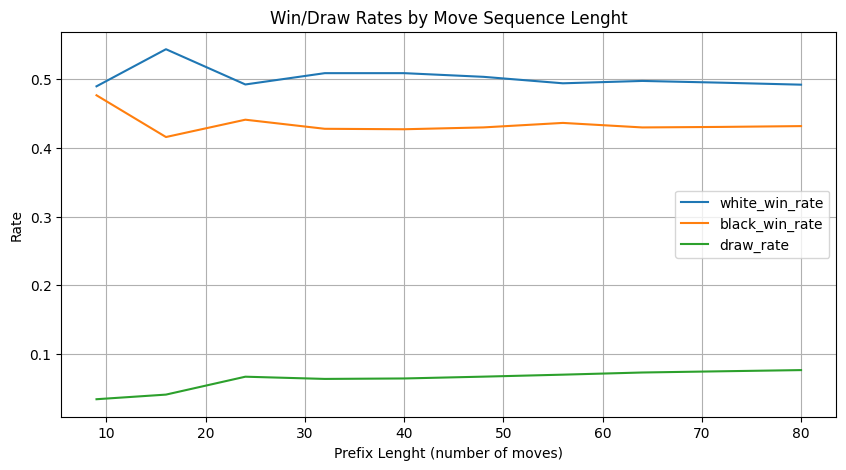

In [54]:
df_prefix["lenght"] = df_prefix["prefix"].apply(len)

rates_by_len = df_prefix.groupby("lenght")[["white_win_rate", "black_win_rate", "draw_rate"]].mean()

rates_by_len.plot(figsize = (10,5))
plt.title("Win/Draw Rates by Move Sequence Lenght")
plt.xlabel("Prefix Lenght (number of moves)")
plt.ylabel("Rate")
plt.grid(True)
plt.show()